# 🏏 IPL Dataset & Analysis Q&A

In [27]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

matches=pd.read_csv("data/matches.csv")
deliveries=pd.read_csv("data/deliveries.csv")

print("matches shape :" , matches.shape)
print("deliveries shape :", deliveries.shape)


matches.head()

matches shape : (1095, 20)
deliveries shape : (260920, 17)


,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [28]:
matches.info()
matches.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1095 non-null   int64  
 1   season           1095 non-null   object 
 2   city             1044 non-null   object 
 3   date             1095 non-null   object 
 4   match_type       1095 non-null   object 
 5   player_of_match  1090 non-null   object 
 6   venue            1095 non-null   object 
 7   team1            1095 non-null   object 
 8   team2            1095 non-null   object 
 9   toss_winner      1095 non-null   object 
 10  toss_decision    1095 non-null   object 
 11  winner           1090 non-null   object 
 12  result           1095 non-null   object 
 13  result_margin    1076 non-null   float64
 14  target_runs      1092 non-null   float64
 15  target_overs     1092 non-null   float64
 16  super_over       1095 non-null   object 
 17  method        

,id,result_margin,target_runs,target_overs
count,1.095000e+03,1076.000000,1092.000000,1092.000000
mean,9.048283e+05,17.259294,165.684066,19.759341
std,3.677402e+05,21.787444,33.427048,1.581108
min,3.359820e+05,1.000000,43.000000,5.000000
25%,5.483315e+05,6.000000,146.000000,20.000000
50%,9.809610e+05,8.000000,166.000000,20.000000
75%,1.254062e+06,20.000000,187.000000,20.000000
max,1.426312e+06,146.000000,288.000000,20.000000


## ❓ Question 1 : Which team has won the most number of matches from 2008 till 2024?

In [29]:
# Checking the names or incosistencies in the team names
win_count=matches['winner'].value_counts()

win_count

winner
Mumbai Indians                 144
Chennai Super Kings            138
Kolkata Knight Riders          131
Royal Challengers Bangalore    116
Rajasthan Royals               112
Kings XI Punjab                 88
Sunrisers Hyderabad             88
Delhi Daredevils                67
Delhi Capitals                  48
Deccan Chargers                 29
Gujarat Titans                  28
Lucknow Super Giants            24
Punjab Kings                    24
Gujarat Lions                   13
Pune Warriors                   12
Rising Pune Supergiant          10
Royal Challengers Bengaluru      7
Kochi Tuskers Kerala             6
Rising Pune Supergiants          5
Name: count, dtype: int64

### Fixing the inconsistent team names

In [30]:
# Fix inconsistent team names

name_mapping = {
    'Royal Challengers Bangalore' : 'Royal Challengers Bengaluru',
    'Delhi Daredevils'            : 'Delhi Capitals',
    'Kings XI Punjab'             : 'Punjab Kings',
    'Rising Pune Supergiant'      : 'Rising Pune Supergiants'
}

# Apply fix to the entire matches dataframe
# anywhere a team name appears

matches['winner']  = matches['winner'].replace(name_mapping)
matches['team1']   = matches['team1'].replace(name_mapping)
matches['team2']   = matches['team2'].replace(name_mapping)

# Verify the fix worked
print(matches['winner'].value_counts())

winner
Mumbai Indians                 144
Chennai Super Kings            138
Kolkata Knight Riders          131
Royal Challengers Bengaluru    123
Delhi Capitals                 115
Rajasthan Royals               112
Punjab Kings                   112
Sunrisers Hyderabad             88
Deccan Chargers                 29
Gujarat Titans                  28
Lucknow Super Giants            24
Rising Pune Supergiants         15
Gujarat Lions                   13
Pune Warriors                   12
Kochi Tuskers Kerala             6
Name: count, dtype: int64


### Now checking and then drawing the information we found out.
### 📊 Visualisation

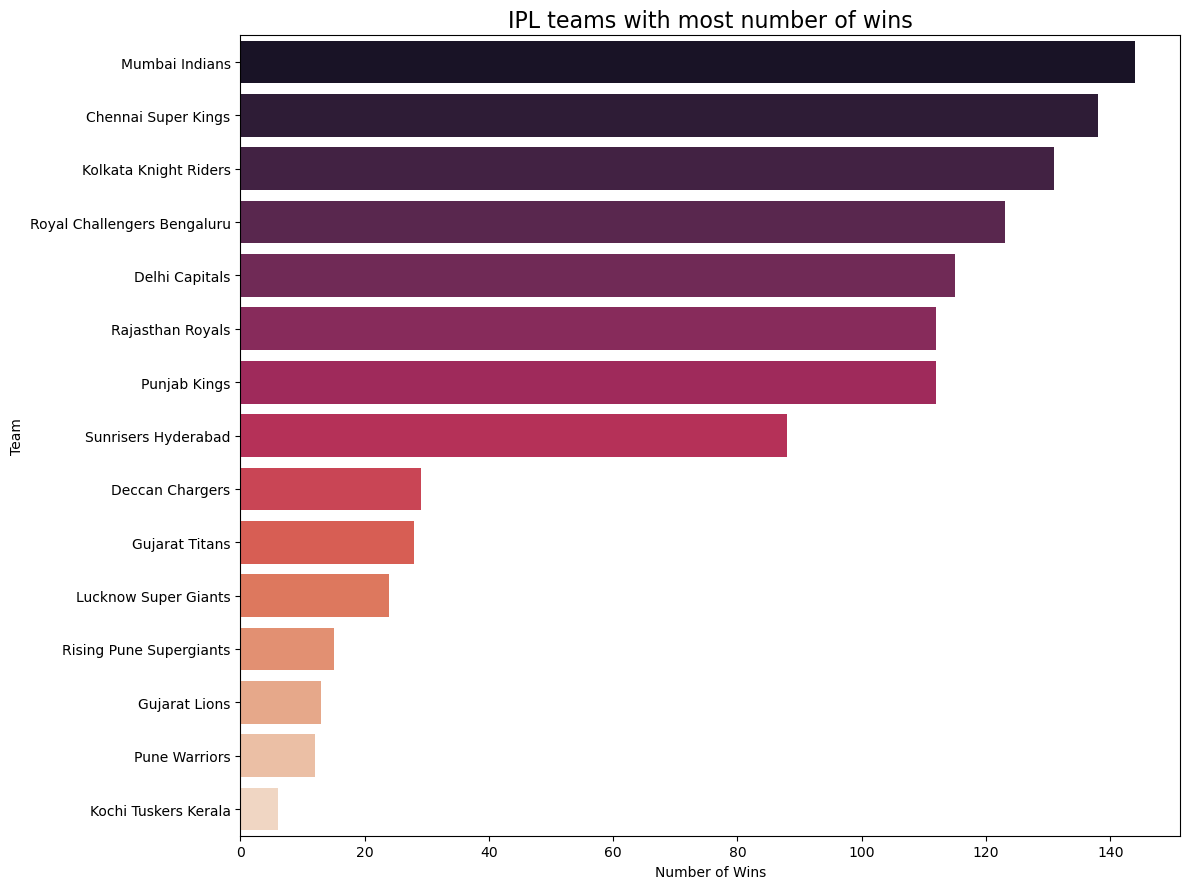

winner
Mumbai Indians                 144
Chennai Super Kings            138
Kolkata Knight Riders          131
Royal Challengers Bengaluru    123
Delhi Capitals                 115
Rajasthan Royals               112
Punjab Kings                   112
Sunrisers Hyderabad             88
Deccan Chargers                 29
Gujarat Titans                  28
Lucknow Super Giants            24
Rising Pune Supergiants         15
Gujarat Lions                   13
Pune Warriors                   12
Kochi Tuskers Kerala             6
Name: count, dtype: int64


In [31]:
# Question 1 - Which team has won the most IPL matches?

plt.figure(figsize=(12, 9))

win_counts = matches['winner'].value_counts()

sns.barplot(x=win_counts.values, y=win_counts.index, hue=win_counts.index, palette='rocket', legend=False)

plt.title('IPL teams with most number of wins', fontsize=16)
plt.xlabel('Number of Wins')
plt.ylabel('Team')
plt.tight_layout()
plt.savefig('chart_q1_team_wins.png', dpi=150, bbox_inches='tight')
plt.show()

print(win_counts)

### 🔍 Observation - Question 1 

- Mumbai Indians are the most successful IPL team in terms of matches they won with 144 wins
- Chennai Super Kings and KKR follow closely behind
- Newer teams like LSG and GT have fewer wins simply due to fewer seasons played
- Terminated franchises like Kochi Tuskers and Pune Warriors had very short runs

## ❓ Question 2 — Does Winning the Toss Actually Help You Win the Match?

In [32]:
# CREATE A NEW COLUMN FOR TOSS WINER AND WIN THE MATCH TEAMS
matches['toss_win_match_win']= matches['toss_winner']==matches['winner']  

# It will create a series of True and False values
toss_effect = matches['toss_win_match_win'].value_counts()

#toss decision
print(matches['toss_decision'].value_counts())

print()
print(toss_effect)
print(f"\nWon toss and won Match : {toss_effect[True]} ({round(toss_effect[True]/toss_effect.sum()*100,2)})")
print(f"\nWon toss and lost Match : {toss_effect[False]} ({round(toss_effect[False]/toss_effect.sum()*100,2)})")

toss_decision
field    704
bat      391
Name: count, dtype: int64

toss_win_match_win
False    674
True     421
Name: count, dtype: int64

Won toss and won Match : 421 (38.45)

Won toss and lost Match : 674 (61.55)


In [33]:
matches['toss_decision'].value_counts()

toss_decision
field    704
bat      391
Name: count, dtype: int64

### 📊 Visualisation

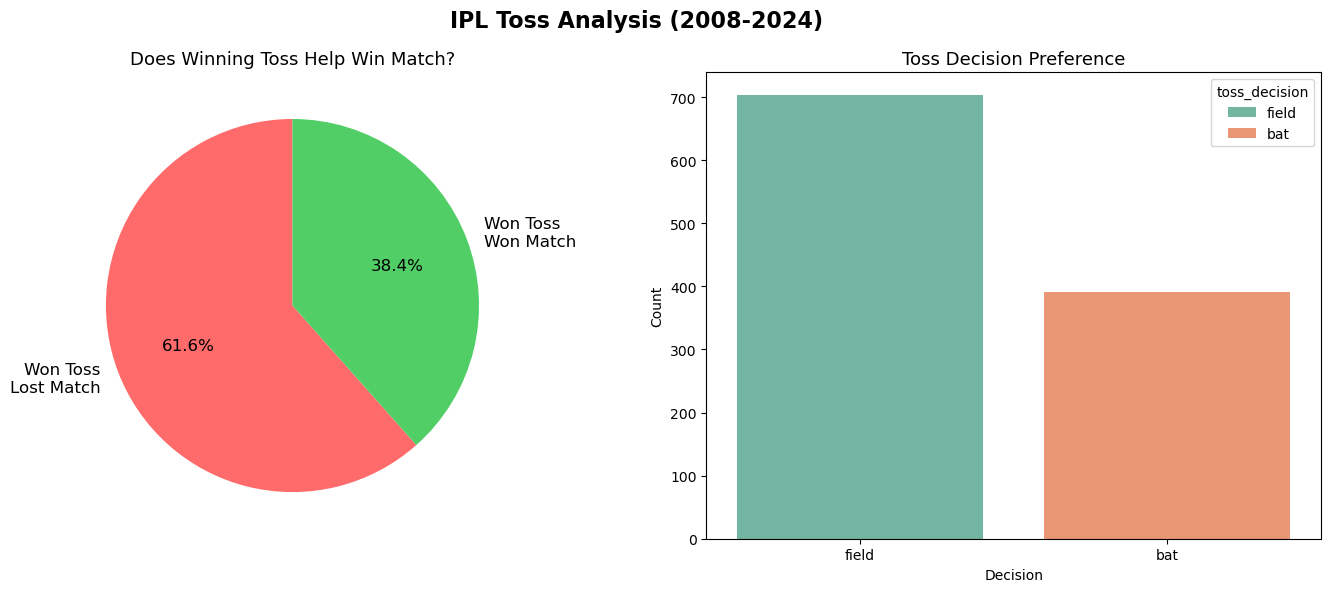

In [34]:
# Question 2 - Toss vs Match Win Visualization

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Plot 1 - Toss winner vs Match winner ---
toss_effect = matches['toss_win_match_win'].value_counts()
labels = ['Won Toss\nLost Match', 'Won Toss\nWon Match']
colors = ['#ff6b6b', '#51cf66']

axes[0].pie(toss_effect.values, 
            labels=labels, 
            colors=colors,
            autopct='%1.1f%%', 
            startangle=90,
            textprops={'fontsize': 12})
axes[0].set_title('Does Winning Toss Help Win Match?', fontsize=13)

# --- Plot 2 - Toss decision preference ---
toss_decision = matches['toss_decision'].value_counts()

sns.barplot(x=toss_decision.index, 
            y=toss_decision.values,
            hue=toss_decision.index,
            palette='Set2',
            legend= True,
            ax=axes[1])
axes[1].set_title('Toss Decision Preference', fontsize=13)
axes[1].set_xlabel('Decision')
axes[1].set_ylabel('Count')

plt.suptitle('IPL Toss Analysis (2008-2024)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('chart_q2_toss_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

### 🔍 Observation - Question 2
- More matches are won by team who lost the toss(61.6% matches are lost are by team who won the toss)
- Pie chart determines that winning toss does not give significant advantage to the team 
- Teams have elected to field first more than batting after winning the toss (704-field)

## ❓ Question 3 - Who Are the Top 10 Run Scorers in IPL History?

In [35]:
deliveries.info()
deliveries.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260920 entries, 0 to 260919
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   match_id          260920 non-null  int64 
 1   inning            260920 non-null  int64 
 2   batting_team      260920 non-null  object
 3   bowling_team      260920 non-null  object
 4   over              260920 non-null  int64 
 5   ball              260920 non-null  int64 
 6   batter            260920 non-null  object
 7   bowler            260920 non-null  object
 8   non_striker       260920 non-null  object
 9   batsman_runs      260920 non-null  int64 
 10  extra_runs        260920 non-null  int64 
 11  total_runs        260920 non-null  int64 
 12  extras_type       14125 non-null   object
 13  is_wicket         260920 non-null  int64 
 14  player_dismissed  12950 non-null   object
 15  dismissal_kind    12950 non-null   object
 16  fielder           9354 non-null    obj

,match_id,inning,over,ball,batsman_runs,extra_runs,total_runs,is_wicket
count,2.609200e+05,260920.000000,260920.000000,260920.000000,260920.000000,260920.000000,260920.000000,260920.000000
mean,9.070665e+05,1.483531,9.197677,3.624486,1.265001,0.067806,1.332807,0.049632
std,3.679913e+05,0.502643,5.683484,1.814920,1.639298,0.343265,1.626416,0.217184
min,3.359820e+05,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,5.483340e+05,1.000000,4.000000,2.000000,0.000000,0.000000,0.000000,0.000000
50%,9.809670e+05,1.000000,9.000000,4.000000,1.000000,0.000000,1.000000,0.000000
75%,1.254066e+06,2.000000,14.000000,5.000000,1.000000,0.000000,1.000000,0.000000
max,1.426312e+06,6.000000,19.000000,11.000000,6.000000,7.000000,7.000000,1.000000


In [36]:
deliveries.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


In [37]:
# Question 3 - Top 10 Run Scorers in IPL History

top_scorers = deliveries.groupby('batter')['batsman_runs'].sum().sort_values(ascending=False).head(10)

print(top_scorers)

batter
V Kohli           8014
S Dhawan          6769
RG Sharma         6630
DA Warner         6567
SK Raina          5536
MS Dhoni          5243
AB de Villiers    5181
CH Gayle          4997
RV Uthappa        4954
KD Karthik        4843
Name: batsman_runs, dtype: int64


### 📊 Visualisation

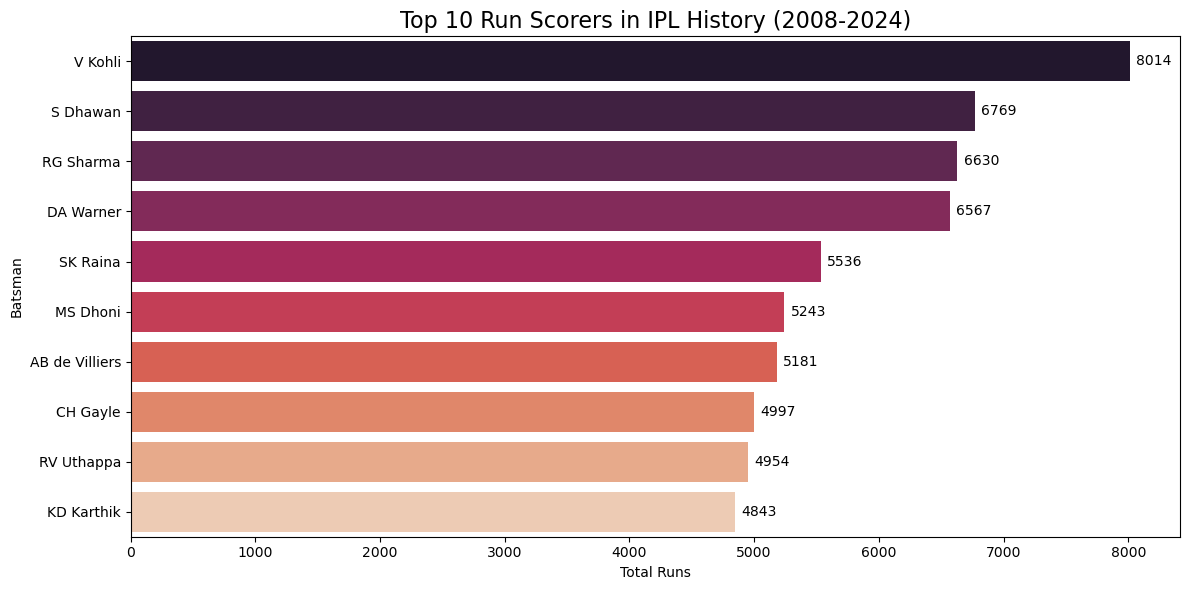

In [38]:
# Question 3 - Top 10 Run Scorers in IPL History

plt.figure(figsize=(12, 6))

sns.barplot(x=top_scorers.values,
            y=top_scorers.index,
            hue=top_scorers.index,
            palette='rocket',
            legend=False)

# Add run count labels at the end of each bar
for i, runs in enumerate(top_scorers.values):
    plt.text(runs + 50, i, str(runs), va='center', fontsize=10)

plt.title('Top 10 Run Scorers in IPL History (2008-2024)', fontsize=16)
plt.xlabel('Total Runs')
plt.ylabel('Batsman')
plt.tight_layout()
plt.savefig('chart_q3_top_scorers.png', dpi=150, bbox_inches='tight')
plt.show()

### 🔍 Observation — Question 3

- Virat Kohli dominates IPL run scoring with 8014 total runs —
  over 1200 runs ahead of second placed Shikhar Dhawan, 
  showing he is in a completely different league

- Dhawan, Rohit Sharma and David Warner are separated by just 
  ~200 runs despite playing for different teams across different 
  seasons — an remarkably close contest for 2nd place

- MS Dhoni's presence at 6th is notable — as a finisher and captain 
  rather than a top order batsman, his 5243 runs reflect 
  exceptional consistency across 17 IPL seasons

- 3 out of the top 10 run scorers are overseas players 
  (Warner, De Villiers, Gayle) highlighting the global 
  talent that IPL attracted from the start

- The 3171 run gap between Kohli (1st) and Karthik (10th) 
  shows how significantly the elite performers separate 
  themselves over a long tournament history

## ❓ Question - 4 Which Venues Have the Highest Average First Innings Score?

In [39]:
print(matches['venue'].value_counts())

venue
Eden Gardens                                                             77
Wankhede Stadium                                                         73
M Chinnaswamy Stadium                                                    65
Feroz Shah Kotla                                                         60
Rajiv Gandhi International Stadium, Uppal                                49
MA Chidambaram Stadium, Chepauk                                          48
Sawai Mansingh Stadium                                                   47
Dubai International Cricket Stadium                                      46
Wankhede Stadium, Mumbai                                                 45
Punjab Cricket Association Stadium, Mohali                               35
Sheikh Zayed Stadium                                                     29
Sharjah Cricket Stadium                                                  28
MA Chidambaram Stadium, Chepauk, Chennai                                 28
Narend

### Fixing the discrepancies in the venue names 
example (Eden Gardens / Eden Gardens, Kolkata ➡️ Eden Gardens)

In [40]:
venue_mapping = {
    # Eden Gardens
    'Eden Gardens, Kolkata'                                          : 'Eden Gardens',
    
    # Wankhede
    'Wankhede Stadium, Mumbai'                                       : 'Wankhede Stadium',
    
    # Chinnaswamy
    'M.Chinnaswamy Stadium'                                          : 'M Chinnaswamy Stadium',
    'M Chinnaswamy Stadium, Bengaluru'                               : 'M Chinnaswamy Stadium',

    # Chepauk
    'MA Chidambaram Stadium, Chepauk, Chennai'                       : 'MA Chidambaram Stadium, Chepauk',
    'MA Chidambaram Stadium'                                         : 'MA Chidambaram Stadium, Chepauk',

    # Rajiv Gandhi
    'Rajiv Gandhi International Stadium'                             : 'Rajiv Gandhi International Stadium, Uppal',
    'Rajiv Gandhi International Stadium, Uppal, Hyderabad'          : 'Rajiv Gandhi International Stadium, Uppal',

    # Arun Jaitley
    'Arun Jaitley Stadium, Delhi'                                    : 'Arun Jaitley Stadium',
    'Feroz Shah Kotla'                                               : 'Arun Jaitley Stadium',

    # PCA Mohali
    'Punjab Cricket Association IS Bindra Stadium, Mohali'          : 'Punjab Cricket Association Stadium, Mohali',
    'Punjab Cricket Association IS Bindra Stadium'                   : 'Punjab Cricket Association Stadium, Mohali',
    'Punjab Cricket Association IS Bindra Stadium, Mohali, Chandigarh' : 'Punjab Cricket Association Stadium, Mohali',

    # DY Patil
    'Dr DY Patil Sports Academy, Mumbai'                             : 'Dr DY Patil Sports Academy',

    # Sawai Mansingh
    'Sawai Mansingh Stadium, Jaipur'                                 : 'Sawai Mansingh Stadium',

    # MCA Pune
    'Maharashtra Cricket Association Stadium, Pune'                  : 'Maharashtra Cricket Association Stadium',
    'Subrata Roy Sahara Stadium'                                     : 'Maharashtra Cricket Association Stadium',

    # Narendra Modi Stadium (renamed from Sardar Patel)
    'Sardar Patel Stadium, Motera'                                   : 'Narendra Modi Stadium, Ahmedabad',

    # Brabourne
    'Brabourne Stadium, Mumbai'                                      : 'Brabourne Stadium',

    # Rajiv Gandhi YS
    'Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium, Visakhapatnam' : 'Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium',

    #Himachal Pradesh Cricket Association Stadium
    'Himachal Pradesh Cricket Association Stadium, Dharamsala' : 'Himachal Pradesh Cricket Association Stadium',
     
    #Sheikh zayed cricket stadium, Abu Dhabi
    'Zayed Cricket Stadium, Abu Dhabi' : 'Sheikh Zayed Stadium',
}

matches['venue'] = matches['venue'].replace(venue_mapping)

# Verify
print(matches['venue'].value_counts().head(20))

venue
Wankhede Stadium                                                         118
M Chinnaswamy Stadium                                                     94
Eden Gardens                                                              93
Arun Jaitley Stadium                                                      90
MA Chidambaram Stadium, Chepauk                                           85
Rajiv Gandhi International Stadium, Uppal                                 77
Punjab Cricket Association Stadium, Mohali                                61
Sawai Mansingh Stadium                                                    57
Maharashtra Cricket Association Stadium                                   51
Dubai International Cricket Stadium                                       46
Dr DY Patil Sports Academy                                                37
Sheikh Zayed Stadium                                                      37
Narendra Modi Stadium, Ahmedabad                                      

Step 1 — Calculate Total Score Per Match Per Inning

In [41]:
# Sum all runs per match per inning
match_innings_score = deliveries.groupby(
                        ['match_id', 'inning'])['total_runs'].sum().reset_index()

# Rename column for clarity
match_innings_score.columns = ['match_id', 'inning', 'total_score']

# Preview
print(match_innings_score.head(10))

   match_id  inning  total_score
0    335982       1          222
1    335982       2           82
2    335983       1          240
3    335983       2          207
4    335984       1          129
5    335984       2          132
6    335985       1          165
7    335985       2          166
8    335986       1          110
9    335986       2          112


Step 2 — Filter Only First Innings

In [42]:
# we'll keep only first innings score 
first_innings = match_innings_score[match_innings_score['inning']==1]

print(first_innings.shape)
print(first_innings.head(10))

(1095, 3)
    match_id  inning  total_score
0     335982       1          222
2     335983       1          240
4     335984       1          129
6     335985       1          165
8     335986       1          110
10    335987       1          166
12    335988       1          142
14    335989       1          208
16    335990       1          214
18    335991       1          182


Step 3 - Merge With Matches to Get Venue Name

In [43]:
# Merge first innings scores with matches to get venue
first_innings_venue = first_innings.merge(
                        matches[['id', 'venue']], 
                        left_on='match_id', 
                        right_on='id')

print(first_innings_venue.head())

   match_id  inning  total_score      id  \
0    335982       1          222  335982   
1    335983       1          240  335983   
2    335984       1          129  335984   
3    335985       1          165  335985   
4    335986       1          110  335986   

                                        venue  
0                       M Chinnaswamy Stadium  
1  Punjab Cricket Association Stadium, Mohali  
2                        Arun Jaitley Stadium  
3                            Wankhede Stadium  
4                                Eden Gardens  


Step 4 — Average First Innings Score Per Venue


In [44]:
# Calculate the average first inning score per venue
venue_avg_score=first_innings_venue.groupby('venue')['total_score'].mean().sort_values(ascending=False).reset_index()

print(venue_avg_score.head(10))

                                          venue  total_score
0  Himachal Pradesh Cricket Association Stadium   183.769231
1           Barsapara Cricket Stadium, Guwahati   180.000000
2                             Brabourne Stadium   178.518519
3                         M Chinnaswamy Stadium   173.191489
4              Narendra Modi Stadium, Ahmedabad   171.555556
5                              Wankhede Stadium   170.254237
6                          Arun Jaitley Stadium   169.322222
7        Saurashtra Cricket Association Stadium   168.900000
8    Punjab Cricket Association Stadium, Mohali   168.278689
9                              Barabati Stadium   167.714286


#### It has one problem that even a stadium with just very less matches is also considered for the highest average first innings score which wouldn't be fair on the stadium who held a minimum number of matches. Therefore, let's make a threshold minimum matches should be played on the venue to be cosidered for the first innings average score. 

In [45]:
# Count matches per venue
venue_match_counts = first_innings_venue.groupby('venue')['match_id'].count().reset_index()
venue_match_counts.columns = ['venue', 'match_count']

# Merge match counts with average scores
venue_avg_score = venue_avg_score.merge(venue_match_counts, on='venue')

# Apply 25 match minimum threshold
venue_avg_score_filtered = venue_avg_score[venue_avg_score['match_count'] >= 30]

print(venue_avg_score_filtered)

                                         venue  total_score  match_count
3                        M Chinnaswamy Stadium   173.191489           94
4             Narendra Modi Stadium, Ahmedabad   171.555556           36
5                             Wankhede Stadium   170.254237          118
6                         Arun Jaitley Stadium   169.322222           90
8   Punjab Cricket Association Stadium, Mohali   168.278689           61
12                                Eden Gardens   166.279570           93
14             MA Chidambaram Stadium, Chepauk   163.894118           85
15         Dubai International Cricket Stadium   163.760870           46
16   Rajiv Gandhi International Stadium, Uppal   162.844156           77
17     Maharashtra Cricket Association Stadium   162.372549           51
18                      Sawai Mansingh Stadium   161.508772           57
21                  Dr DY Patil Sports Academy   159.648649           37
24                        Sheikh Zayed Stadium   15

### 📊 Visualisation

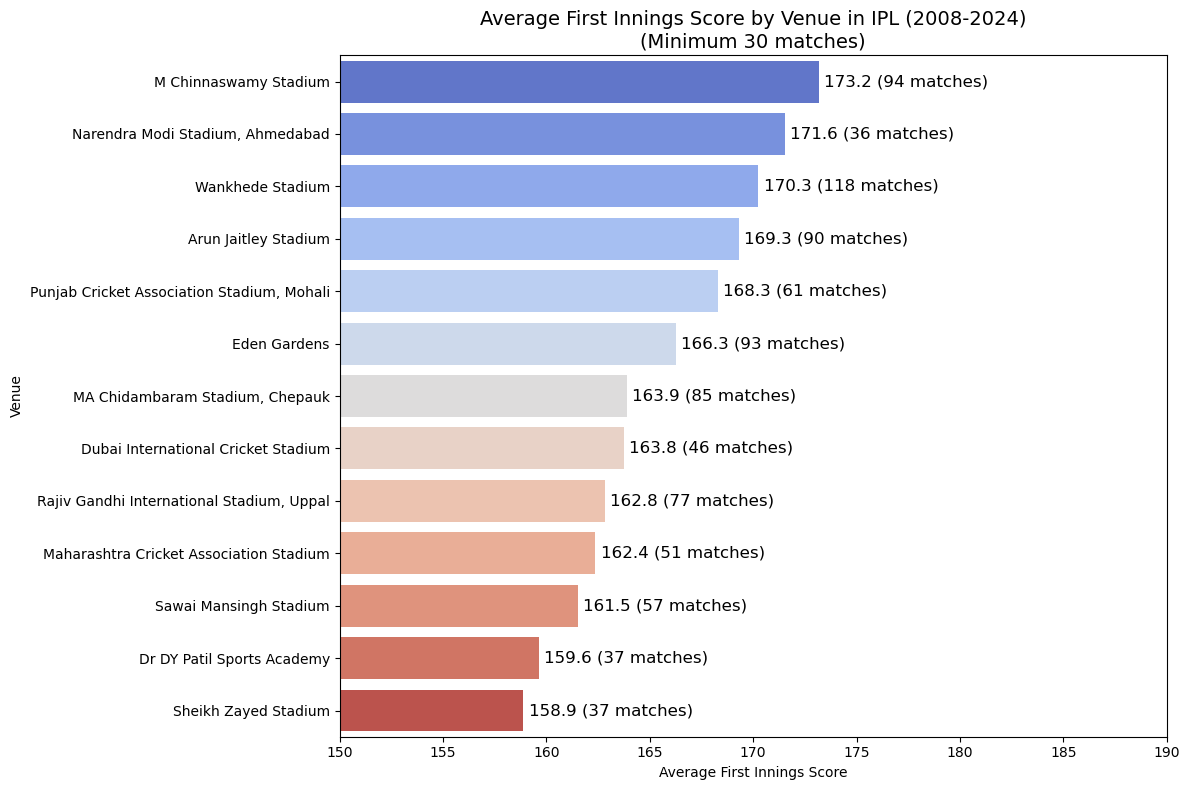

In [46]:
# Question 4 - Venues with Highest Average First Innings Score

plt.figure(figsize=(12, 8))

sns.barplot(x='total_score',
            y='venue',
            hue='venue',
            data=venue_avg_score_filtered.sort_values('total_score', ascending=False),
            palette='coolwarm',
            legend=False)

# Add score labels at end of each bar
for i, (score, count) in enumerate(zip(venue_avg_score_filtered.sort_values('total_score', ascending=False)['total_score'],
                                        venue_avg_score_filtered.sort_values('total_score', ascending=False)['match_count'])):
    plt.text(score + 0.25, i, f'{score:.1f} ({count} matches)', va='center', fontsize=12)

plt.title('Average First Innings Score by Venue in IPL (2008-2024)\n(Minimum 30 matches)', fontsize=14)
plt.xlabel('Average First Innings Score')
plt.ylabel('Venue')
plt.xlim(150, 190)
plt.tight_layout()
plt.savefig('chart_q4_venue_scores.png', dpi=150, bbox_inches='tight')
plt.show()

### 🔍 Observation — Question 4
- M Chinnaswamy Stadium leads the chart with highest average first innings score of 173.2 runs across 94 matches.

- Venues like Chepauk, Dubai International Cricket Stadium (used only during COVID seasons 2020-2021), MCA Stadium and Rajiv Gandhi Stadium have the surprisingly close average first innings score, ranging between 163 to 162 runs.

- Interestingly, PCA Stadium Mohali has a higher average score 
of 168 runs than Eden Gardens — despite Eden Gardens being known 
for its good batting friendly surface.

- One of the frequently used ground Sawai Mansingh Stadium has the lowest average first innings score among all major established venues on this list.

- There is gap of nearly 15 runs between highest and lowest ranked venues on the list,highlighting the venue and pitch conditions significantly impact the average first innings score.

## ❓ Question - 5 How Has Average Team Score Per Season Changed From 2008 to 2024?

Step 1 - Checking the columns name in the matches dataframe and season format

In [47]:
print(matches.columns.tolist())
print(matches['season'].value_counts().sort_index())

['id', 'season', 'city', 'date', 'match_type', 'player_of_match', 'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner', 'result', 'result_margin', 'target_runs', 'target_overs', 'super_over', 'method', 'umpire1', 'umpire2', 'toss_win_match_win']
season
2007/08    58
2009       57
2009/10    60
2011       73
2012       74
2013       76
2014       60
2015       59
2016       60
2017       59
2018       60
2019       60
2020/21    60
2021       60
2022       74
2023       74
2024       71
Name: count, dtype: int64


Fixing the season names format

In [48]:
season_mapping = {
    '2007/08' : '2008',
    '2009/10' : '2010',
    '2020/21' : '2020'
}

matches['season'] = matches['season'].replace(season_mapping)

# Verify
print(matches['season'].value_counts().sort_index())

season
2008    58
2009    57
2010    60
2011    73
2012    74
2013    76
2014    60
2015    59
2016    60
2017    59
2018    60
2019    60
2020    60
2021    60
2022    74
2023    74
2024    71
Name: count, dtype: int64


In [49]:
# both innings score
innings_score=deliveries.groupby('match_id')['total_runs'].sum().reset_index()
innings_score.columns=['match_id','total_score']
print(innings_score)

      match_id  total_score
0       335982          304
1       335983          447
2       335984          261
3       335985          331
4       335986          222
...        ...          ...
1090   1426307          429
1091   1426309          323
1092   1426310          346
1093   1426311          314
1094   1426312          227

[1095 rows x 2 columns]


Step 2 — Merge Season Into Innings Data

In [50]:
# Bring season column into innings_score
innings_score_season = innings_score.merge(
                            matches[['id', 'season']],
                            left_on='match_id',
                            right_on='id')
print(innings_score_season)
print(innings_score_season.columns.tolist())

      match_id  total_score       id season
0       335982          304   335982   2008
1       335983          447   335983   2008
2       335984          261   335984   2008
3       335985          331   335985   2008
4       335986          222   335986   2008
...        ...          ...      ...    ...
1090   1426307          429  1426307   2024
1091   1426309          323  1426309   2024
1092   1426310          346  1426310   2024
1093   1426311          314  1426311   2024
1094   1426312          227  1426312   2024

[1095 rows x 4 columns]
['match_id', 'total_score', 'id', 'season']


Step 3 — Calculate Average Score Per Season

In [51]:
season_avg_score = innings_score_season.groupby('season')['total_score'].mean().reset_index()
season_avg_score.columns = ['season', 'avg_score']

print(season_avg_score)

   season   avg_score
0    2008  309.258621
1    2009  286.894737
2    2010  314.716667
3    2011  289.780822
4    2012  303.418919
5    2013  297.394737
6    2014  315.516667
7    2015  311.067797
8    2016  314.366667
9    2017  318.406780
10   2018  331.683333
11   2019  323.900000
12   2020  323.600000
13   2021  310.616667
14   2022  329.662162
15   2023  347.135135
16   2024  365.788732


### 📊 Visualisation

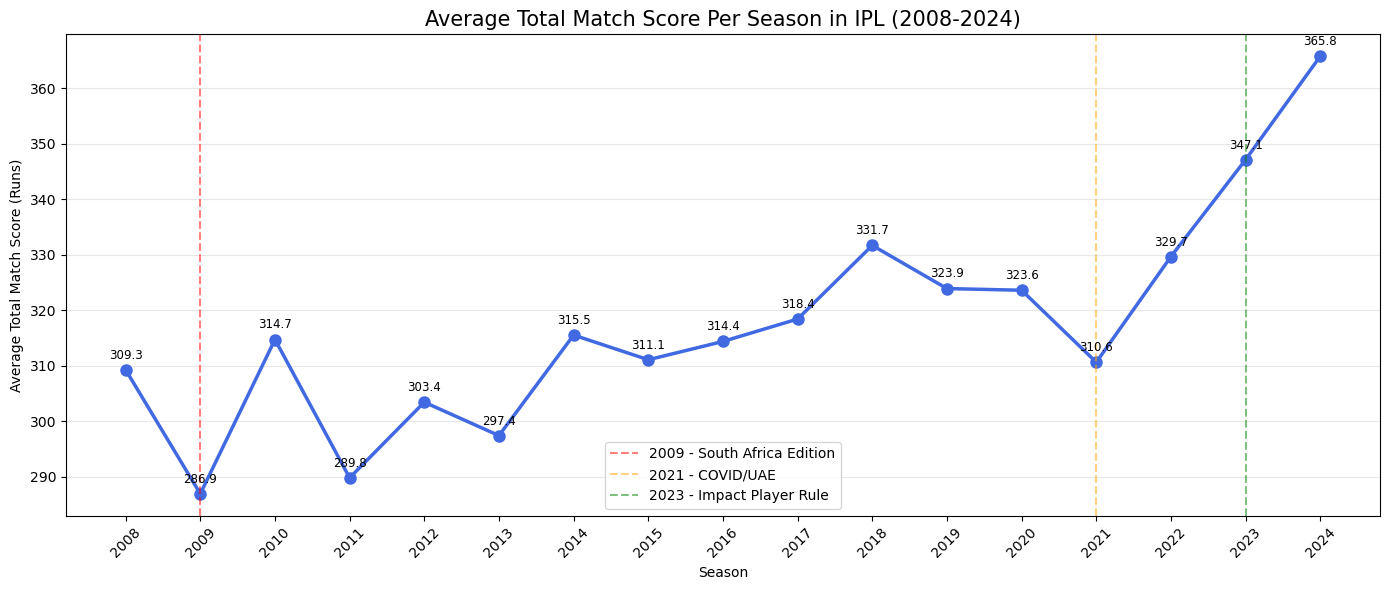

In [52]:
# Question 5 - Average Total Match Score Per Season

plt.figure(figsize=(14, 6))

plt.plot(season_avg_score['season'],
         season_avg_score['avg_score'],
         'o-',
         linewidth=2.5,
         markersize=8,
         color='royalblue')

# Add value labels on each point
for i, row in season_avg_score.iterrows():
    plt.text(row['season'],
             row['avg_score'] + 2,
             f"{row['avg_score']:.1f}",
             ha='center',
             fontsize=8.5)

# Highlight notable seasons with vertical lines
plt.axvline(x='2009', color='red', linestyle='--', alpha=0.5, label='2009 - South Africa Edition')
plt.axvline(x='2021', color='orange', linestyle='--', alpha=0.5, label='2021 - COVID/UAE')
plt.axvline(x='2023', color='green', linestyle='--', alpha=0.5, label='2023 - Impact Player Rule')

plt.title('Average Total Match Score Per Season in IPL (2008-2024)', fontsize=15)
plt.xlabel('Season')
plt.ylabel('Average Total Match Score (Runs)')
plt.xticks(rotation=45)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('chart_q5_season_trends.png', dpi=150, bbox_inches='tight')
plt.show()

### 🔍 Observation — Question 5

- In the inaugural IPL season of 2008, the average total match score 
was 309.3 runs per match.

- Interestingly, 2009 recorded a sudden dip in average scores as the 
entire tournament was held in South Africa, where bouncy and 
pace-friendly pitches naturally favoured bowlers over batsmen.

- Between years 2014 to 2017 the per season runs remained consistent 
and did not fluctuate much, ranging between 315 to 318 runs.

- In 2021, a COVID-19 outbreak within the bio-bubble forced the 
tournament to be suspended mid-season and later resumed in the UAE. 
Slower UAE pitches dragged the average total match score down to 310.6 runs.

- The Impact Player rule, introduced in 2023, allowed teams to 
substitute one player mid-match — effectively enabling an extra 
batter in the lineup. This directly contributed to a sharp rise 
in average scores from 2023 onwards.

- The Chart shows that 2024 recorded the highest ever average total match score of 365.8 runs.
The gap of nearly 80 runs between the highest scoring season (2024) and the lowest (2009) highlights how dramatically IPL scoring has evolved over 17 seasons.
 

## ✅ Conclusion

This analysis of IPL data spanning 17 seasons (2008–2024) 
reveals several interesting patterns about the tournament's 
evolution and competitive dynamics.

Mumbai Indians stand out as the most dominant franchise with 
144 wins — significantly ahead of all other teams — reflecting 
their consistent squad building and leadership over the years.

Perhaps the most surprising finding is that winning the toss 
provides no significant match winning advantage — only 38% of 
toss winners go on to win the match. This suggests that team 
quality and execution matter far more than the toss outcome.

Individually, Virat Kohli's dominance as IPL's all time leading 
run scorer with 8014 runs — over 1200 runs ahead of second place 
— highlights his extraordinary consistency across all 17 seasons.

Venue and pitch conditions emerged as a significant factor, with 
M Chinnaswamy Stadium recording the highest average first innings 
score of 173 runs across 94 matches, while spin friendly venues 
like Chepauk consistently produced lower scores around 163 runs.

Most strikingly, IPL scoring has evolved dramatically over 17 
seasons — from an average of 309 runs per match(both-innings) in 2008 to 365 
runs in 2024. Rule changes like the Impact Player rule, improved 
batting technology, and shorter boundaries have collectively 
transformed IPL into an even more high scoring spectacle.

### 🔭 Future Scope
This analysis could be extended to explore:
- Impact of home vs away conditions on team win rates
- Bowler economy rates across seasons and venues
- Correlation between auction price and player performance
- Effect of the Impact Player rule on individual player statistics